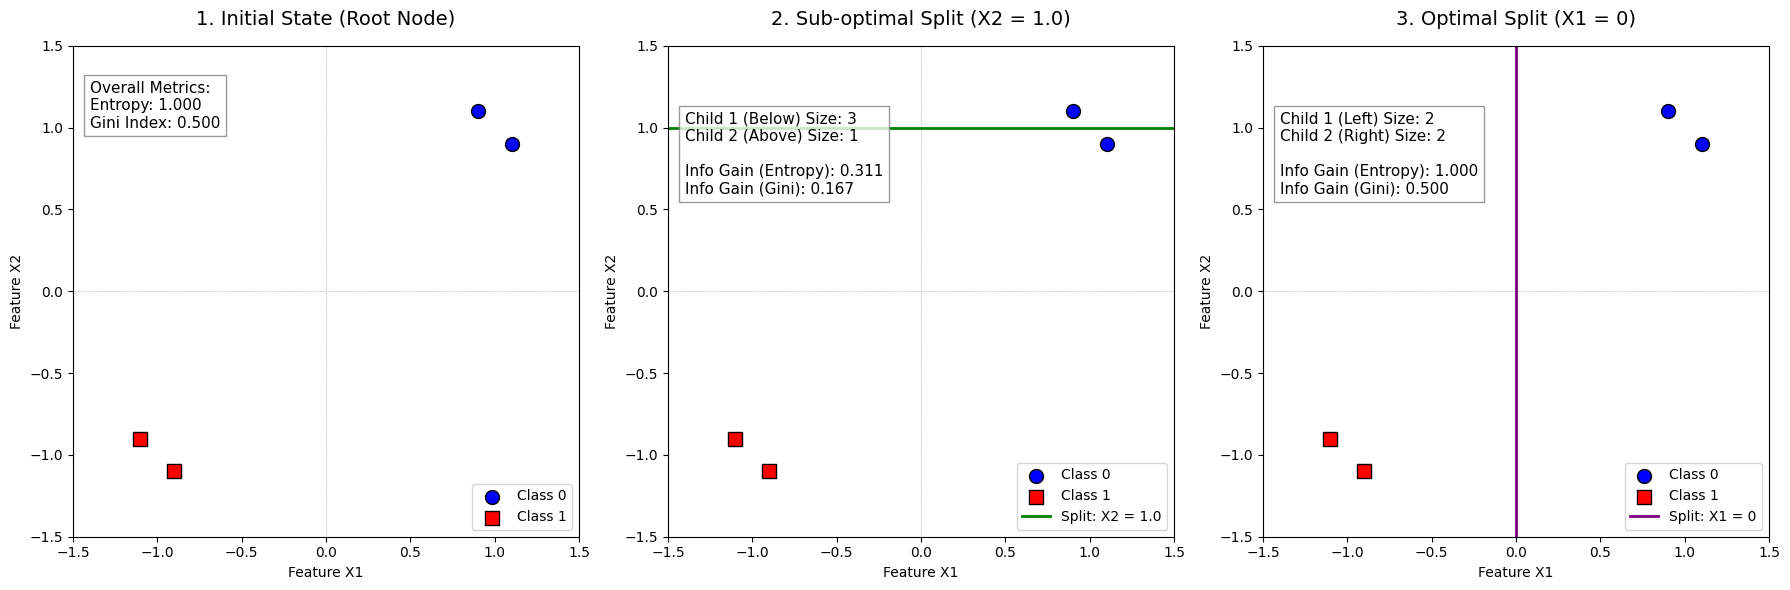

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Loss and Gain Functions ---

def calculate_entropy(y):
    """Calculates the Shannon entropy of a label array."""
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y == 1) / len(y)
    p0 = 1.0 - p1
    if p0 == 0 or p1 == 0:
        return 0.0
    return -p0 * np.log2(p0) - p1 * np.log2(p1)

def calculate_gini(y):
    """Calculates the Gini impurity of a label array."""
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y == 1) / len(y)
    p0 = 1.0 - p1
    return 1.0 - (p0**2 + p1**2)

def information_gain(y_parent, y_left, y_right, metric='entropy'):
    """Calculates Information Gain based on the chosen metric."""
    if metric == 'entropy':
        loss_parent = calculate_entropy(y_parent)
        loss_left = calculate_entropy(y_left)
        loss_right = calculate_entropy(y_right)
    elif metric == 'gini':
        loss_parent = calculate_gini(y_parent)
        loss_left = calculate_gini(y_left)
        loss_right = calculate_gini(y_right)
        
    weight_left = len(y_left) / len(y_parent)
    weight_right = len(y_right) / len(y_parent)
    
    return loss_parent - (weight_left * loss_left + weight_right * loss_right)

# --- 2. Create the Dataset ---

# 4 points: Two near (1, 1) Class 0, Two near (-1, -1) Class 1
X = np.array([[0.9, 1.1], [1.1, 0.9], [-0.9, -1.1], [-1.1, -0.9]])
y = np.array([0, 0, 1, 1])

# --- 3. Visualization Setup ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)

# Helper function to plot points
def plot_data(ax, title):
    ax.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', s=100, label='Class 0', edgecolors='k')
    ax.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', s=100, marker='s', label='Class 1', edgecolors='k')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Feature X1")
    ax.set_ylabel("Feature X2")
    ax.legend(loc='lower right')

# --- Scenario A: Initial State (Root Node) ---
ax = axes[0]
plot_data(ax, "1. Initial State (Root Node)")
ent = calculate_entropy(y)
gini = calculate_gini(y)

text_initial = f"Overall Metrics:\nEntropy: {ent:.3f}\nGini Index: {gini:.3f}"
ax.text(-1.4, 1.0, text_initial, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# --- Scenario B: Sub-optimal Split (e.g., Feature X2 = 1.0) ---
ax = axes[1]
plot_data(ax, "2. Sub-optimal Split (X2 = 1.0)")
split_val_y = 1.0
ax.axhline(split_val_y, color='green', linewidth=2, label='Split: X2 = 1.0')
ax.legend(loc='lower right')

# Calculate split metrics
mask_left = X[:, 1] <= split_val_y  # Below the line
mask_right = X[:, 1] > split_val_y   # Above the line

ig_entropy = information_gain(y, y[mask_left], y[mask_right], metric='entropy')
ig_gini = information_gain(y, y[mask_left], y[mask_right], metric='gini')

text_suboptimal = (f"Child 1 (Below) Size: {sum(mask_left)}\n"
                   f"Child 2 (Above) Size: {sum(mask_right)}\n\n"
                   f"Info Gain (Entropy): {ig_entropy:.3f}\n"
                   f"Info Gain (Gini): {ig_gini:.3f}")
ax.text(-1.4, 0.6, text_suboptimal, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))


# --- Scenario C: Optimal Split (e.g., Feature X1 = 0) ---
ax = axes[2]
plot_data(ax, "3. Optimal Split (X1 = 0)")
split_val_x = 0.0
ax.axvline(split_val_x, color='purple', linewidth=2, label='Split: X1 = 0')
ax.legend(loc='lower right')

# Calculate split metrics
mask_left_opt = X[:, 0] <= split_val_x  # Left of the line
mask_right_opt = X[:, 0] > split_val_x  # Right of the line

ig_entropy_opt = information_gain(y, y[mask_left_opt], y[mask_right_opt], metric='entropy')
ig_gini_opt = information_gain(y, y[mask_left_opt], y[mask_right_opt], metric='gini')

text_optimal = (f"Child 1 (Left) Size: {sum(mask_left_opt)}\n"
                f"Child 2 (Right) Size: {sum(mask_right_opt)}\n\n"
                f"Info Gain (Entropy): {ig_entropy_opt:.3f}\n"
                f"Info Gain (Gini): {ig_gini_opt:.3f}")
ax.text(-1.4, 0.6, text_optimal, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

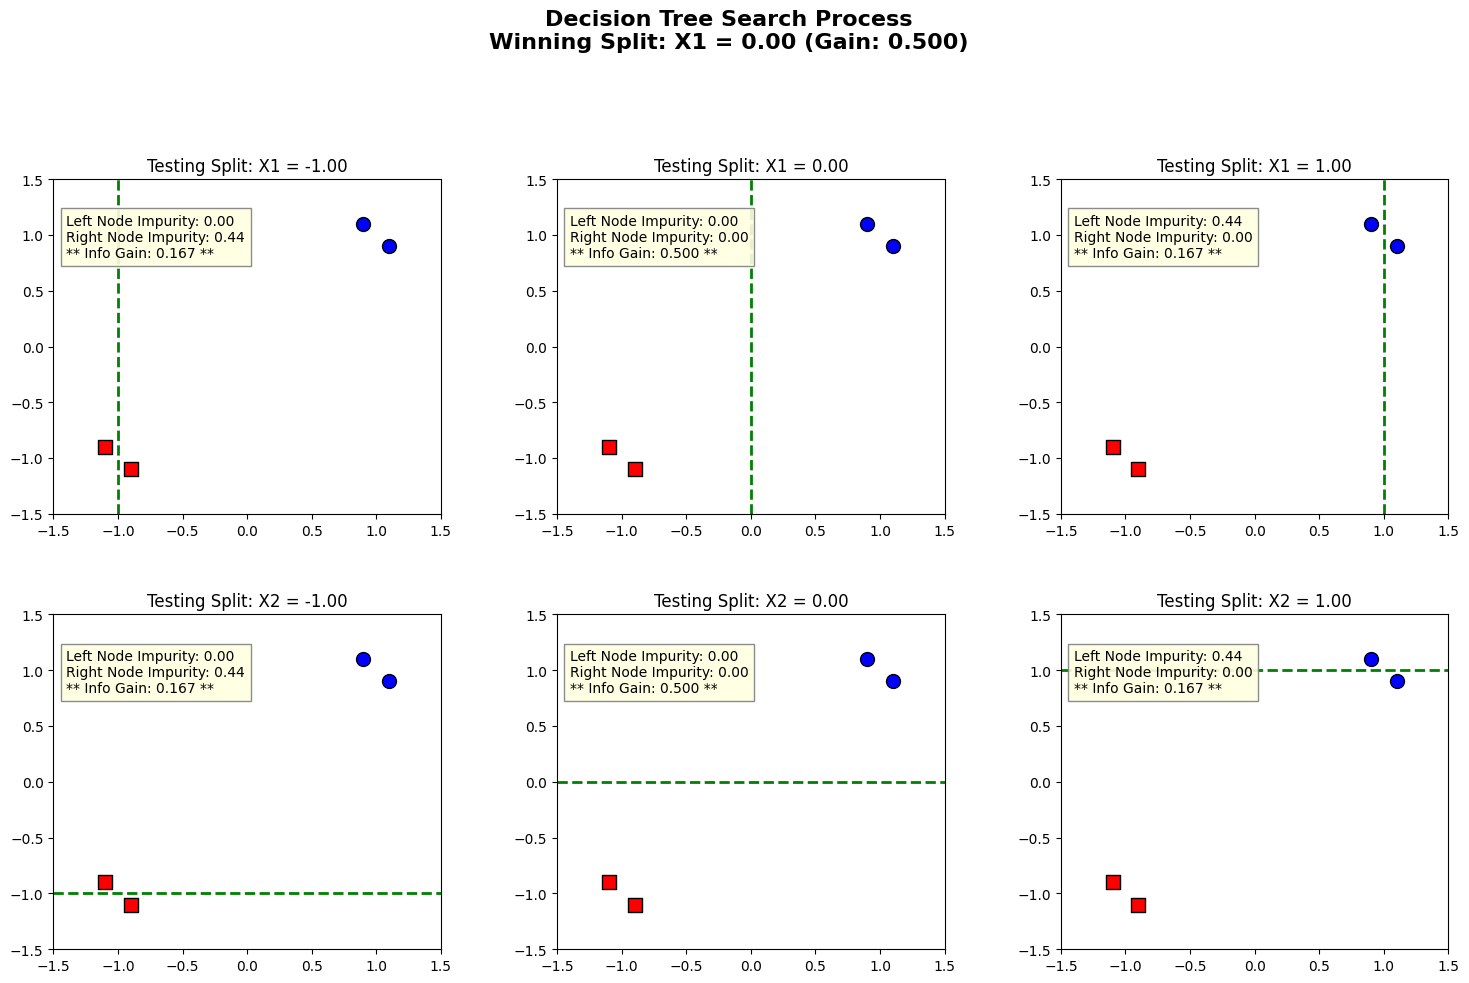

<Figure size 640x480 with 0 Axes>

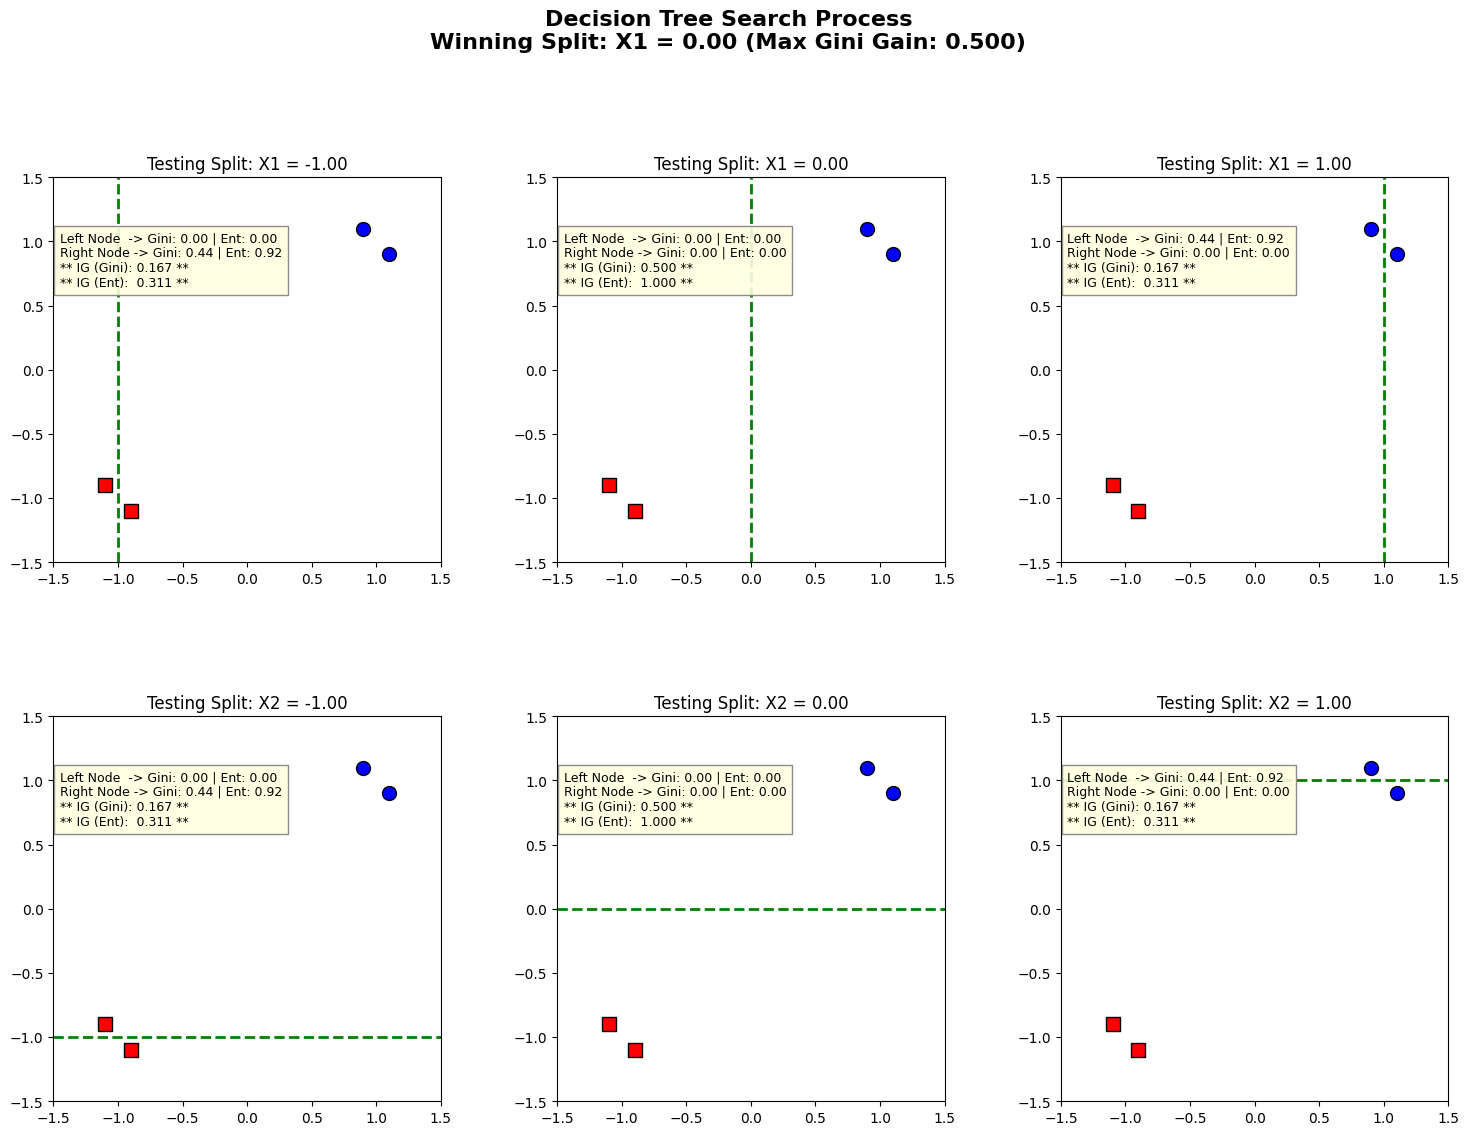

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Loss and Gain Functions ---

def calculate_gini(y):
    """Calculates the Gini impurity of a label array."""
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y == 1) / len(y)
    p0 = 1.0 - p1
    return 1.0 - (p0**2 + p1**2)

def calculate_entropy(y):
    """Calculates the Shannon entropy of a label array."""
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y == 1) / len(y)
    p0 = 1.0 - p1
    if p0 == 0 or p1 == 0:
        return 0.0
    return -p0 * np.log2(p0) - p1 * np.log2(p1)

def information_gain(y_parent, y_left, y_right, metric='gini'):
    """Calculates Information Gain using Gini or Entropy."""
    if metric == 'gini':
        loss_parent = calculate_gini(y_parent)
        loss_left = calculate_gini(y_left)
        loss_right = calculate_gini(y_right)
    else:
        loss_parent = calculate_entropy(y_parent)
        loss_left = calculate_entropy(y_left)
        loss_right = calculate_entropy(y_right)
        
    weight_left = len(y_left) / len(y_parent)
    weight_right = len(y_right) / len(y_parent)
    
    return loss_parent - (weight_left * loss_left + weight_right * loss_right)

# --- 2. Create the Dataset ---
# 4 points: Two near (1, 1) Class 0, Two near (-1, -1) Class 1
X = np.array([[0.9, 1.1], [1.1, 0.9], [-0.9, -1.1], [-1.1, -0.9]])
y = np.array([0, 0, 1, 1])

# --- 3. The Decision Tree "Thought Process" ---

# Find candidate thresholds for each feature (midpoints between unique values)
candidate_splits = {}
for feature_idx in range(X.shape[1]):
    unique_vals = np.sort(np.unique(X[:, feature_idx]))
    # Calculate midpoints between adjacent sorted values
    midpoints = (unique_vals[:-1] + unique_vals[1:]) / 2.0
    candidate_splits[feature_idx] = midpoints

# Setup visualization (2 features, 3 candidate splits each = 6 plots)
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Increased height slightly for more text
plt.subplots_adjust(hspace=0.4, wspace=0.3)
axes = axes.flatten()

best_gain_gini = -1
best_split = None
plot_idx = 0

# The core search loop: Iterate over features and their candidate thresholds
for feature_idx, thresholds in candidate_splits.items():
    for threshold in thresholds:
        
        # Perform the split
        mask_left = X[:, feature_idx] <= threshold
        mask_right = X[:, feature_idx] > threshold
        
        y_left = y[mask_left]
        y_right = y[mask_right]
        
        # Calculate the gain for both metrics
        gain_gini = information_gain(y, y_left, y_right, metric='gini')
        gain_entropy = information_gain(y, y_left, y_right, metric='entropy')
        
        # Track the best split (Using Gini as the primary decision maker)
        if gain_gini > best_gain_gini:
            best_gain_gini = gain_gini
            best_split = (feature_idx, threshold)
            
        # --- Visualization for this iteration ---
        ax = axes[plot_idx]
        
        # Plot data
        ax.scatter(X[y==0][:, 0], X[y==0][:, 1], color='blue', s=100, label='Class 0', edgecolors='k')
        ax.scatter(X[y==1][:, 0], X[y==1][:, 1], color='red', s=100, marker='s', label='Class 1', edgecolors='k')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        
        # Draw the candidate split line
        feature_name = f"X{feature_idx + 1}"
        if feature_idx == 0:
            ax.axvline(threshold, color='green', linestyle='--', linewidth=2)
        else:
            ax.axhline(threshold, color='green', linestyle='--', linewidth=2)
            
        # Annotate with metrics
        ax.set_title(f"Testing Split: {feature_name} = {threshold:.2f}", fontsize=12)
        
        # Combined metrics text
        metrics_text = (f"Left Node  -> Gini: {calculate_gini(y_left):.2f} | Ent: {calculate_entropy(y_left):.2f}\n"
                        f"Right Node -> Gini: {calculate_gini(y_right):.2f} | Ent: {calculate_entropy(y_right):.2f}\n"
                        f"** IG (Gini): {gain_gini:.3f} **\n"
                        f"** IG (Ent):  {gain_entropy:.3f} **")
        
        # Highlight if it's a positive gain
        bbox_color = 'lightyellow' if gain_gini > 0 else 'white'
        ax.text(-1.45, 0.65, metrics_text, fontsize=9, 
                bbox=dict(facecolor=bbox_color, alpha=0.9, edgecolor='gray'))
        
        plot_idx += 1

# --- 4. Highlight the Final Decision ---
plt.suptitle(f"Decision Tree Search Process\nWinning Split: X{best_split[0] + 1} = {best_split[1]:.2f} (Max Gini Gain: {best_gain_gini:.3f})", 
             fontsize=16, fontweight='bold', y=1.02)

plt.show()
plt.savefig("test.png")